#### Dataset

- Name: Iris Dataset
- Task: Unsupervised Learning - Clustering
- Source: Scikit-Learn Built-in Dataset
- Samples: 150
- Features: 4
- Reference: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html


<h1> DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

At K-Means we said:</br>
"I want to divide the data into K groups."

But DBSCAN says:</br>
"See where the data has high density and find the groups myself."

The core idea of ​​DBSCAN

DBSCAN operates based on density.

That is:

If there is a sufficient number of samples around a point:
That point is part of a cluster.

There are three main concepts:
1. Epsilon (eps)
The radius of the neighborhood.
Meaning:
At what distance do we consider points to be neighbors?

2. Min Samples
The minimum number of points required to form a dense region.

3. Core Point
A point where:
the number of neighbors ≥ min_samples.

Types of Points in DBSCAN
DBSCAN has three types of points:
1. Core Point
A point that has sufficient density.

2. Border Point
A point that does not have sufficient density itself but is located next to a Core Point.

3. Noise Point
A point that has no nearby Core Point.

Start

 |

Select an unvisited point

 |

Find neighbors within eps

 |

Is number of neighbors >= min_samples?

       /        \
     Yes         No

     |            |

Core Point     Noise

     |

Create Cluster

     |

Expand Cluster

     |

Repeat

In [19]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

from src.dbscan import DBSCAN

from sklearn.cluster import DBSCAN as SKDBSCAN

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.metrics import adjusted_rand_score

<h3> Step 1: Make Moons Dataset

The make_moons dataset generates two crescent-shaped clusters.

In [2]:
X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)

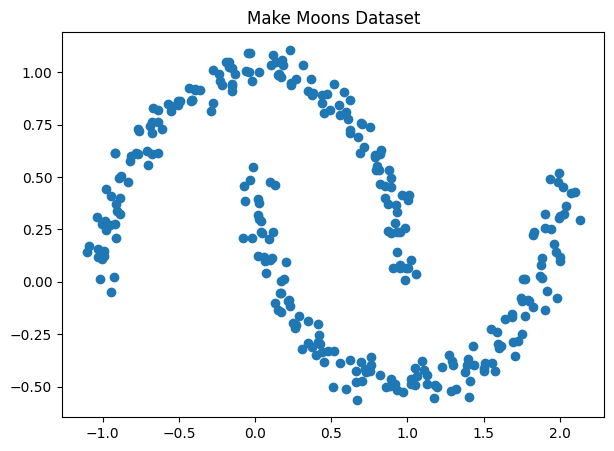

In [3]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X[:,0],
    X[:,1]
)

plt.title(
    "Make Moons Dataset"
)

plt.show()

<h3> Step 2: Manual implementation of DBSCAN

In [4]:
dbscan_custom = DBSCAN(
    eps=0.2,
    min_samples=5
)

dbscan_custom.fit(
    X
)

labels_custom = (
    dbscan_custom.labels
)

In [5]:
neighbors = dbscan_custom._region_query(
    X,
    0
)

print(len(neighbors))
print(neighbors[:10])

18
[0, 17, 34, 119, 144, 158, 160, 171, 180, 193]


In [6]:
print(
    dbscan_custom.labels[:50]
)

[0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 1 0 1 1 0 1 1
 1 1 1 1 1 0 1 1 1 0 0 1 0]


In [7]:
np.unique(
    labels_custom,
    return_counts=True
)

(array([0, 1]), array([150, 150], dtype=int64))

<h3> Step 3: Visualization of Custom DBSCAN

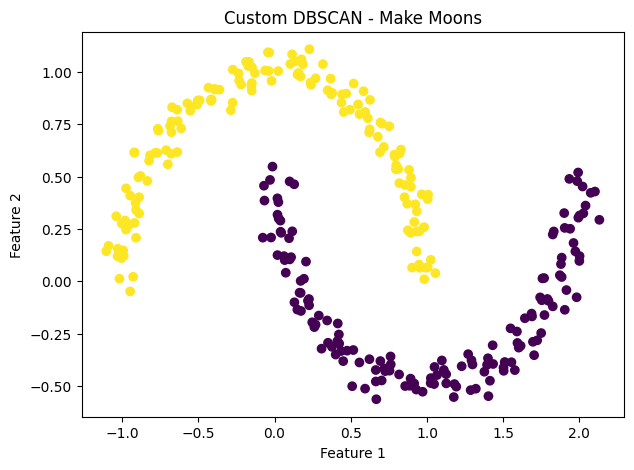

In [8]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels_custom
)

plt.title(
    "Custom DBSCAN - Make Moons"
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.show()

<h3> Step 4: Scikit-Learn DBSCAN Implementation

In [10]:
sklearn_dbscan = SKDBSCAN(
    eps=0.2,
    min_samples=5
)

sklearn_labels = sklearn_dbscan.fit_predict(
    X
)

np.unique(
    sklearn_labels,
    return_counts=True
)

(array([0, 1], dtype=int64), array([150, 150], dtype=int64))

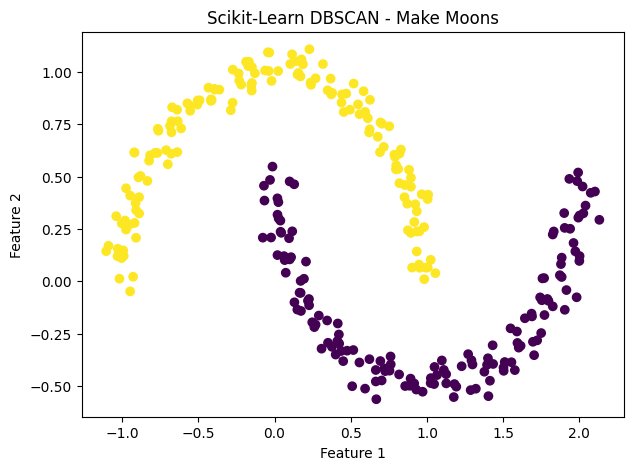

In [11]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=sklearn_labels
)

plt.title(
    "Scikit-Learn DBSCAN - Make Moons"
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.show()

<h3> Step 5: DBSCAN on Iris Dataset

In [13]:
iris = load_iris()

X = iris.data
y = iris.target

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

In [14]:
iris_dbscan_custom = DBSCAN(
    eps=0.8,
    min_samples=5
)

iris_dbscan_custom.fit(
    X_scaled
)

iris_labels_custom = (
    iris_dbscan_custom.labels
)

np.unique(
    iris_labels_custom,
    return_counts=True
)

(array([-1,  0,  1]), array([ 4, 49, 97], dtype=int64))

<h3> Step 6: Visualization with PCA

In [16]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

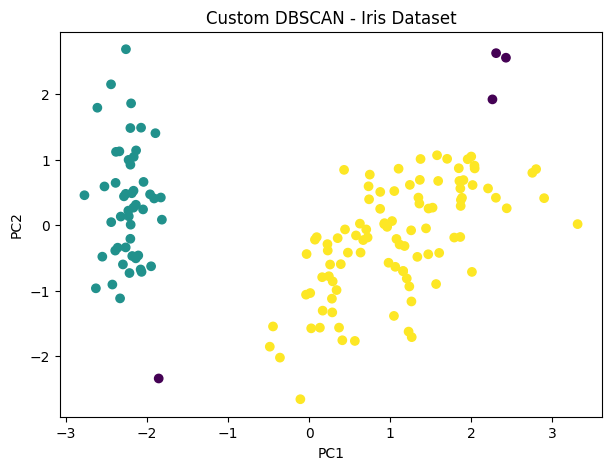

In [17]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=iris_labels_custom
)

plt.title(
    "Custom DBSCAN - Iris Dataset"
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.show()

However, unlike K-Means:</br>
DBSCAN did not create exactly three clusters.</br>
This is because its goal is to identify density, not to find the actual Iris classes.

<h3> Step 7: Final Comparison — Custom DBSCAN vs Scikit-Learn DBSCAN

In [28]:
sklearn_dbscan = SKDBSCAN(
    eps=0.8,
    min_samples=5
)

sklearn_labels = sklearn_dbscan.fit_predict(
    X_scaled
)

In [29]:
custom_unique, custom_counts = np.unique(
    iris_labels_custom,
    return_counts=True
)

sk_unique, sk_counts = np.unique(
    sklearn_labels,
    return_counts=True
)

print("Custom DBSCAN:")
for label, count in zip(custom_unique, custom_counts):
    print(
        f"Label {label}: {count} samples"
    )

print("\nSklearn DBSCAN:")
for label, count in zip(sk_unique, sk_counts):
    print(
        f"Label {label}: {count} samples"
    )

Custom DBSCAN:
Label -1: 4 samples
Label 0: 49 samples
Label 1: 97 samples

Sklearn DBSCAN:
Label -1: 4 samples
Label 0: 49 samples
Label 1: 97 samples


Versicolor and Virginica:

These two species:
- Have more similar features.
- Overlap in the feature space.
Therefore, DBSCAN treats them as a single dense region.

### DBSCAN on Iris Dataset

DBSCAN was applied to the Iris dataset after feature standardization.

Unlike K-Means, DBSCAN does not require the number of clusters to be specified beforehand. The algorithm automatically discovered dense regions in the dataset.

The clustering result:

| Label | Samples |
|---|---:|
|-1 (Noise)|4|
|Cluster 0|49|
|Cluster 1|97|

The custom implementation produced exactly the same clustering result as Scikit-Learn DBSCAN.

The algorithm identified two main dense regions and classified four samples as noise. The reason for finding two clusters instead of three is that Iris Versicolor and Iris Virginica have overlapping feature distributions, causing DBSCAN to consider them part of the same density region.

<h3> Step 8: Adjusted Rand Index (ARI)

ARI measures the degree of similarity between two partitions.
In other words, how have the two models partitioned the data?

General formula:

$ARI = \frac{RI - Expected(RI)}
{max(RI)-Expected(RI)}$

In [27]:
ari_custom_sklearn = adjusted_rand_score(
    iris_labels_custom,
    sklearn_labels
)

ari_custom_truth = adjusted_rand_score(
    y,
    iris_labels_custom
)

ari_sklearn_truth = adjusted_rand_score(
    y,
    sklearn_labels
)

print(
    "Custom vs Sklearn:",
    ari_custom_sklearn
)

print(
    "Custom vs Ground Truth:",
    ari_custom_truth
)

print(
    "Sklearn vs Ground Truth:",
    ari_sklearn_truth
)

Custom vs Sklearn: 1.0
Custom vs Ground Truth: 0.5517553852833211
Sklearn vs Ground Truth: 0.5517553852833211


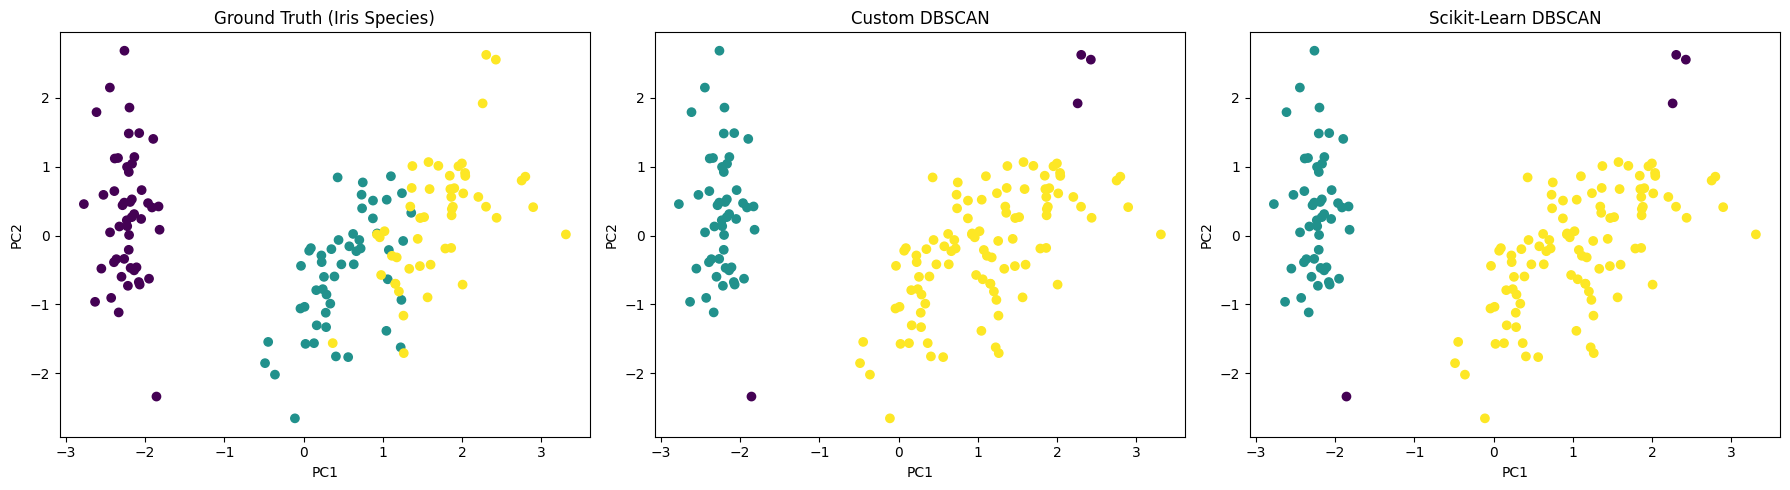

In [24]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)


# Ground Truth
axes[0].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y
)

axes[0].set_title(
    "Ground Truth (Iris Species)"
)

axes[0].set_xlabel(
    "PC1"
)

axes[0].set_ylabel(
    "PC2"
)



# Custom DBSCAN
axes[1].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=iris_labels_custom
)

axes[1].set_title(
    "Custom DBSCAN"
)

axes[1].set_xlabel(
    "PC1"
)

axes[1].set_ylabel(
    "PC2"
)


# Sklearn DBSCAN
axes[2].scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=sklearn_labels
)

axes[2].set_title(
    "Scikit-Learn DBSCAN"
)

axes[2].set_xlabel(
    "PC1"
)

axes[2].set_ylabel(
    "PC2"
)


plt.tight_layout()

plt.show()

### DBSCAN Visualization Analysis

DBSCAN was evaluated on the Iris dataset using PCA visualization.

The custom implementation produced exactly the same clustering result as Scikit-Learn DBSCAN.

Both models discovered:

| Label | Samples |
|---|---:|
|Noise (-1)|4|
|Cluster 0|49|
|Cluster 1|97|

The visualization shows that Setosa forms a clearly separated dense region, while Versicolor and Virginica have overlapping feature distributions and are grouped into the same density-based cluster.

The Adjusted Rand Index between the custom implementation and Scikit-Learn reached 1.0, confirming identical clustering behavior.

The difference between DBSCAN clusters and the original Iris labels highlights that clustering algorithms discover data density structures rather than predefined classes.